# __Classification Problem Set 2__

The main topic for this problem set is to get hands-on experience with features, classifier selection, and training/testing. The task should preferably be implemented in MATLAB or Python.

A small labeled dataset consisting of three spoken vowels and three features extracted from each recording, so-called formants shall be used in this assignment. These formants represent the three frequencies where the sound has its largest peaks in the frequency spectrum. Typical formant frequencies differ from vowel to vowel, but also show significant variation within each class, and we thus have a classical non-separable problem. This exercise will only look at the vowels ’ae,’ ’ah,’ and ’aw,’ which are, however, quite similar/overlapping.

The data is found inside the ”Vowels” folder, where the waveform files have five-letter names, always ending with the extension ”.wav” and the formants are stored inside the ”.dat” file (the two files contain the same values only the explanatory text differs). The ”.wav” files have five letter names where the first letter indicates man/female/boy/girl, the next two represent the person number, and the last two indicate the vowel name. 

__Extract the first three formants (F1, F2, F3) for the vowels ”ae”, ”ah”, and ”aw”, and the corresponding waveform files, giving 139 recordings of each vowel class.__

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
file_path = 'Wovels/vowdata_nohead.dat'

try:
    df = pd.read_csv(file_path, sep='\s+', header=None)
    # print(df)

except FileNotFoundError:
    print(f"File '{file_path}' not found.")
except Exception as e:
    print(f"An error occured: {e}")

df_ae = df[df[0].str.endswith('ae')]
df_ah = df[df[0].str.endswith('ah')]
df_aw = df[df[0].str.endswith('aw')]
print(len(df_ae), len(df_ah), len(df_aw)) # this one should equal 139, 139, 139

F1_ae, F2_ae, F3_ae = df_ae[3].values, df_ae[4].values, df_ae[5].values
F1_ah, F2_ah, F3_ah = df_ah[3].values, df_ah[4].values, df_ah[5].values
F1_aw, F2_aw, F3_aw = df_aw[3].values, df_aw[4].values, df_aw[5].values

139 139 139


### __Problem 1__

__(a)__  Listen to some of the vowels. Note that the recordings have the form of consonant-vowel-consonant
(CVC). Did you have problems discriminating between them? If so, which classes did you find most
confusable?

In [47]:
import IPython.display as ipd
from IPython.display import display, HTML, Audio
import glob

In [48]:
# Find a few files for each vowel across all subfolders
for vowel in ['ae', 'ah', 'aw']:
    files = glob.glob(f'Wovels/**/*{vowel}.wav', recursive=True)
    print(f"\nVowel '{vowel}' — playing: {files[0]}")
    display(Audio(files[0]))



Vowel 'ae' — playing: Wovels/men/m21ae.wav



Vowel 'ah' — playing: Wovels/men/m10ah.wav



Vowel 'aw' — playing: Wovels/men/m44aw.wav


__(b) Generate class-based histograms for the three formants using the training set. Also, generate 2D plots of respectively “F1-F2”, “F1-F3”, and “F2-F3” values for each class. Discuss the discrimination potential of each formant and formant-pair.__

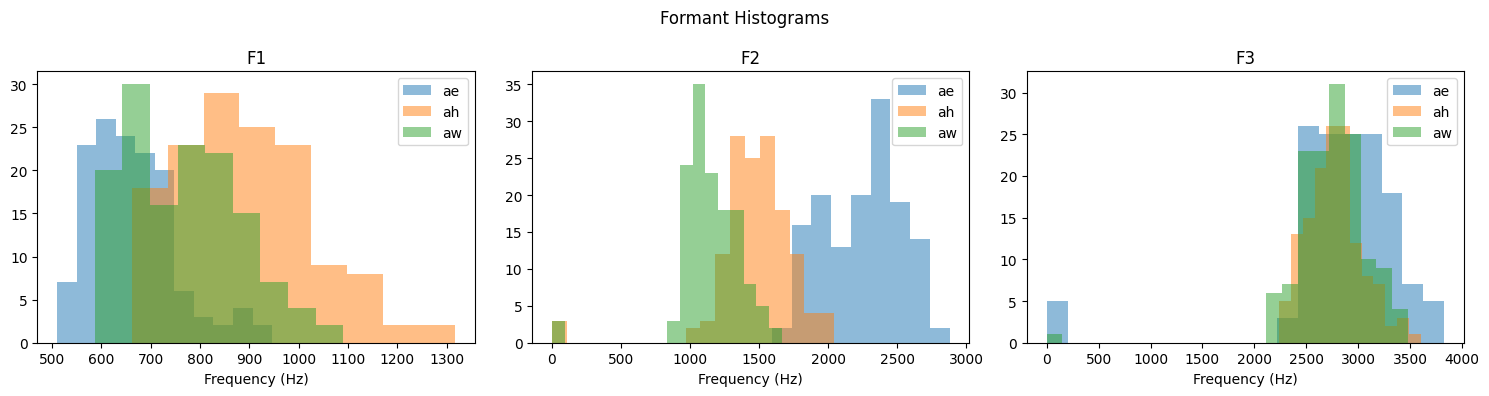

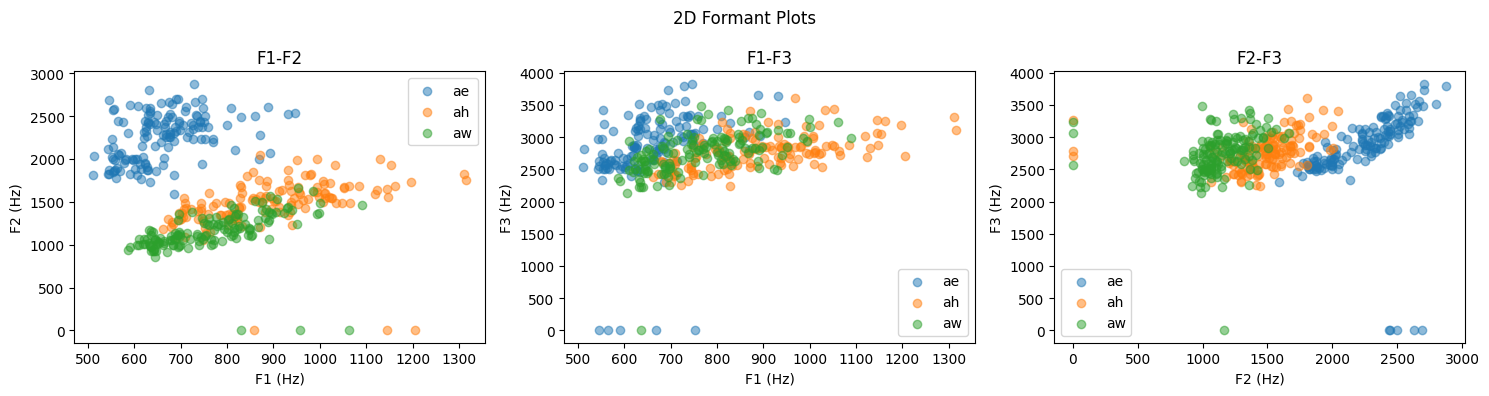

In [49]:
classes = {
    'ae': (F1_ae, F2_ae, F3_ae),
    'ah': (F1_ah, F2_ah, F3_ah),
    'aw': (F1_aw, F2_aw, F3_aw)
}

# --- Histograms ---
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for vowel, (F1, F2, F3) in classes.items():
    for i, formant in enumerate([F1, F2, F3]):
        axs[i].hist(formant, bins='auto', alpha=0.5, label=vowel)
        axs[i].set_title(f'F{i+1}')
        axs[i].set_xlabel('Frequency (Hz)')
        axs[i].legend()

plt.suptitle('Formant Histograms')
plt.tight_layout()
plt.show()

# --- 2D Scatter Plots ---
pairs = [(0, 1, 'F1-F2'), (0, 2, 'F1-F3'), (1, 2, 'F2-F3')]

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for ax, (xi, yi, title) in zip(axs, pairs):
    for vowel, (F1, F2, F3) in classes.items():
        formants = [F1, F2, F3]
        ax.scatter(formants[xi], formants[yi], alpha=0.5, label=vowel)
    ax.set_xlabel(['F1', 'F2', 'F3'][xi] + ' (Hz)')
    ax.set_ylabel(['F1', 'F2', 'F3'][yi] + ' (Hz)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('2D Formant Plots')
plt.tight_layout()
plt.show()


F1 formant has similar distribution between the vowels and the distributions overlap alot, but not as much as F3, it is a poor classifier. In F2 and F3 the distributions vary a bit more. Furthermore, F2 is good at separating AW from AE as their distributions barely overlap, it is by far the best single formant for classification. F3 is more similar between the vowels. F3 alone is not a good feature for vowel classification as there is almost complete overlap, thus it adds almost no information for separating the three vowels. (F2 separates well because of phonetics. F2 measure how far forward a tongue is when speaking. 'ae' in had is front vowel - tongue sits near front of mout. 'ah' and 'aw' are back vowels, tongue is pulled back. So the pysics of mouth explains the data) 

It is clear that AE is most likely the easiest to identify since all its formants pairs differs from the other two vowels. There is less difference from AH and AW, which indicates that the model may struggle with separating these two vowels from each other. F1-F2 is best pair for classification as everything partially overlaps but things are distinguishable. F1-F3 data heavily overlaps. F2-F3 'ae' is separated, but does not help separate 'ah' form 'aw'. 

### __Problem 2__

Assume you have chosen to use a single Gaussian for each class model. Define the first 70 samples of each class as set 1 and the last 69 samples as set 2.

In [50]:
s1_ae = df_ae[:70]
s2_ae = df_ae[70:]
s1_ah = df_ah[:70]
s2_ah = df_ah[70:]
s1_aw = df_aw[:70]
s2_aw = df_aw[70:]

__(a)__ Train the classifier using set 1 as the training set.

In [51]:
# Stack F1, F2, F3 into (70, 3) arrays for each class
train_ae = np.column_stack([s1_ae[3].values, s1_ae[4].values, s1_ae[5].values])
train_ah = np.column_stack([s1_ah[3].values, s1_ah[4].values, s1_ah[5].values])
train_aw = np.column_stack([s1_aw[3].values, s1_aw[4].values, s1_aw[5].values])

# Estimate parameters for each class
models = {}
for vowel, data in [('ae', train_ae), ('ah', train_ah), ('aw', train_aw)]:
    models[vowel] = {
        'mean': np.mean(data, axis=0),        # shape (3,)
        'cov':  np.cov(data, rowvar=False)    # shape (3,3)
    }

# Inspect what was learned
for vowel, params in models.items():
    print(f"{vowel}: mean = {params['mean'].round(1)}")


ae: mean = [ 620.5 2066.6 2732.9]
ah: mean = [ 814.  1388.3 2629.4]
aw: mean = [ 706.  1087.9 2614.4]


__(b)__  Test the classifier using set 2. Find the error rate and the confusion matrix both for the training set and the test set.

Training error rate: 0.0714
Test error rate:     0.1932


/var/folders/hg/c6trnw2j33144_d8wp0zymlc0000gn/T/ipykernel_38359/211959589.py:28: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  error_rate = np.sum(y_true[k] != y_pred[k] for k in range(len(y_true))) / len(y_true)


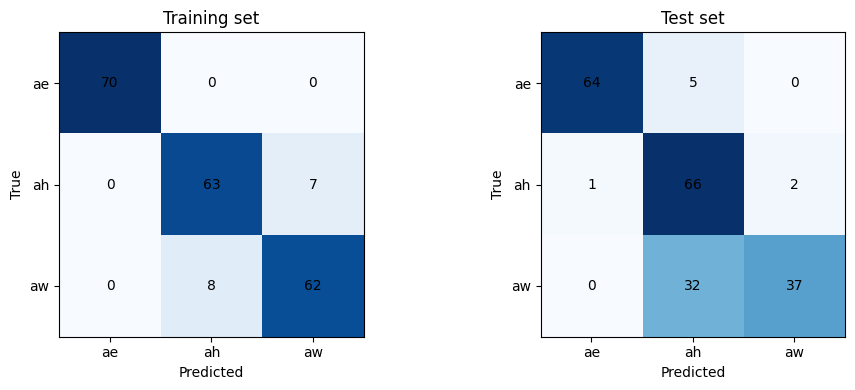

In [52]:
from scipy.stats import multivariate_normal

def classify(sample, models):
    # compute likelihood of this sample under each class's Gaussian
    likelihoods = {
        vowel: multivariate_normal.pdf(sample, mean=params['mean'], cov=params['cov'])
        for vowel, params in models.items()
    }
    return max(likelihoods, key=likelihoods.get)  # return class with highest likelihood

def evaluate(data_dict, models):
    # data_dict: {'ae': (N,3) array, 'ah': (N,3) array, 'aw': (N,3) array}
    vowel_order = ['ae', 'ah', 'aw']
    y_true, y_pred = [], []

    for true_label, data in data_dict.items():
        for sample in data:
            y_true.append(true_label)
            y_pred.append(classify(sample, models))

    # confusion matrix (3x3)
    conf = np.zeros((3, 3), dtype=int)
    for true, pred in zip(y_true, y_pred):
        i = vowel_order.index(true)
        j = vowel_order.index(pred)
        conf[i, j] += 1

    error_rate = np.sum(y_true[k] != y_pred[k] for k in range(len(y_true))) / len(y_true)
    return conf, error_rate

# training data (already have these)
train_data = {
    'ae': train_ae,  # (70, 3)
    'ah': train_ah,
    'aw': train_aw
}

# test data — same stacking as training
test_ae = np.column_stack([s2_ae[3].values, s2_ae[4].values, s2_ae[5].values])
test_ah = np.column_stack([s2_ah[3].values, s2_ah[4].values, s2_ah[5].values])
test_aw = np.column_stack([s2_aw[3].values, s2_aw[4].values, s2_aw[5].values])
test_data = {'ae': test_ae, 'ah': test_ah, 'aw': test_aw}

# evaluate on both
train_conf, train_err = evaluate(train_data, models)
test_conf,  test_err  = evaluate(test_data,  models)

print(f"Training error rate: {train_err:.4f}")
print(f"Test error rate:     {test_err:.4f}")

# plot confusion matrices
vowel_order = ['ae', 'ah', 'aw']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, conf, title in zip(axes, [train_conf, test_conf], ['Training set', 'Test set']):
    im = ax.imshow(conf, cmap='Blues')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, conf[i,j], ha='center', va='center')
    ax.set_xticks([0,1,2]); ax.set_xticklabels(vowel_order)
    ax.set_yticks([0,1,2]); ax.set_yticklabels(vowel_order)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
plt.tight_layout()
plt.show()


almost half of 'aw' is misclassified as 'ah'. For true 'ah', it is mostly correct though. When going back to problem 1, we can check the overlap in feature space between 'ah' and 'aw', especially when F3 is involved. Meanwhile 'ae' is mostly correct.

__(c)__ Repeat the above but now use set 2 as the training set and set 1 as the test set.

Set 2 training error rate: 0.1304
Set 1 test error rate:     0.4000


/var/folders/hg/c6trnw2j33144_d8wp0zymlc0000gn/T/ipykernel_38359/211959589.py:28: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  error_rate = np.sum(y_true[k] != y_pred[k] for k in range(len(y_true))) / len(y_true)


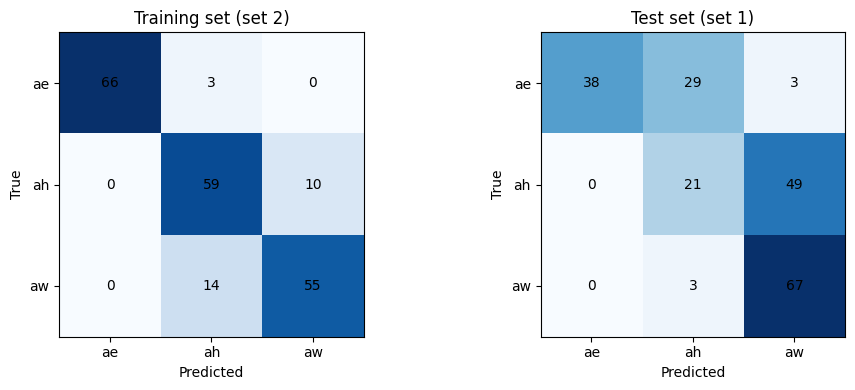

In [53]:
# Train on set 2 (last 69 samples)
train_ae_s2 = np.column_stack([s2_ae[3].values, s2_ae[4].values, s2_ae[5].values])
train_ah_s2 = np.column_stack([s2_ah[3].values, s2_ah[4].values, s2_ah[5].values])
train_aw_s2 = np.column_stack([s2_aw[3].values, s2_aw[4].values, s2_aw[5].values])

# Build models from set 2
models_s2 = {}
for vowel, data in [('ae', train_ae_s2), ('ah', train_ah_s2), ('aw', train_aw_s2)]:
    models_s2[vowel] = {
        'mean': np.mean(data, axis=0),
        'cov':  np.cov(data, rowvar=False)
    }

# Evaluate on training set (set 2) and test set (set 1)
train_s2_data = {'ae': train_ae_s2, 'ah': train_ah_s2, 'aw': train_aw_s2}
test_s2_data  = {'ae': train_ae,    'ah': train_ah,    'aw': train_aw}   # set 1 is now the test set

train_s2_conf, train_s2_err = evaluate(train_s2_data, models_s2)
test_s2_conf,  test_s2_err  = evaluate(test_s2_data,  models_s2)

print(f"Set 2 training error rate: {train_s2_err:.4f}")
print(f"Set 1 test error rate:     {test_s2_err:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, conf, title in zip(axes, [train_s2_conf, test_s2_conf], ['Training set (set 2)', 'Test set (set 1)']):
    im = ax.imshow(conf, cmap='Blues')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, conf[i,j], ha='center', va='center')
    ax.set_xticks([0,1,2]); ax.set_xticklabels(['ae','ah','aw'])
    ax.set_yticks([0,1,2]); ax.set_yticklabels(['ae','ah','aw'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
plt.tight_layout()
plt.show()


so here we check if the model behave similarly regardless of data. we check stability - do results change alot when you swicth datasets. we check generalizetion - does the model work well on any unseen data. i would have expected that 'ae' was still easy and 'ah' and 'aw' is still confusing. but as we see from plots, 'aw' is now easiest. there is now confusion between 'ae' and 'ah' but also 'ah' and 'aw'.

So, model is sensitive to the training data distribution. Set 1 and Set 2 are not identical, this means that mu changes and covariances change. 

__(d)__  Discuss the difference in performance with respect to training versus test set. Further, discuss the
variation in test performance for the two cases.

The confusion matrices for set 1 agrees with the initial expression whereas the second case differences. 

The evaluation on the test set is worse than the training for both set 1 and set 2 which makes sense since these values are previously "unseen" to the model. There is in addition a great difference between the two sets, where training the model on the latter samples yield a worse generalization performance to unseen data. 

Looking at the distribution of speakers in the data some conclusions can be drawn for the great difference between sets. In set 2 the model trains on women and children, and is evaluated on men and women (see figure below). It thus makes sense that the model struggles more since men tend to have a deeper voice than children and women (which sound more alike), and it is something the model has not seen before. Listening to one vowel recording from each group confirms the suspected difference (see below)

__(e)__  Do the confusion matrices agree with your subjective impression from Problem 1?

Yes, the confusion matrices agree with the subjective impression from Problem 1. When listening, 'ae' (as in "had") was the most distinguishable vowel, which is reflected in the low error rate for the ae class. 'ah' and 'aw' were the hardest to tell apart by ear, and the confusion matrices confirm this — the majority of misclassifications are ah↔aw confusions. This is consistent with the histogram and scatter plot analysis showing that ae has a clearly separated F2 distribution (~2067 Hz) compared to ah (~1388 Hz) and aw (~1088 Hz), while ah and aw overlap heavily across all three formants.